In [2]:
from datascience import *
path_data = '../../data/data8/'
import numpy as np
np.set_printoptions(threshold=50)

In [28]:
import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

In [5]:
!ls ../../data/data8 | rg agesex

nc-est2014-agesex-res.csv
nc-est2015-agesex-res.csv
nc-est2019-agesex-res.csv


In [ ]:
# As of August 2021, this census file is online here: 
# data = 'http://www2.census.gov/programs-surveys/popest/technical-documentation/file-layouts/2010-2019/nc-est2019-agesex-res.csv'


In [3]:
data = path_data + "nc-est2019-agesex-res.csv"
full_census = Table.read_table(data)

In [7]:
full_census

SEX,AGE,CENSUS2010POP,ESTIMATESBASE2010,POPESTIMATE2010,POPESTIMATE2011,POPESTIMATE2012,POPESTIMATE2013,POPESTIMATE2014,POPESTIMATE2015,POPESTIMATE2016,POPESTIMATE2017,POPESTIMATE2018,POPESTIMATE2019
0,0,3944153,3944160,3951430,3963092,3926570,3931258,3954787,3983981,3954773,3893990,3815343,3783052
0,1,3978070,3978090,3957730,3966225,3977549,3942698,3948891,3973133,4002903,3972711,3908830,3829599
0,2,4096929,4096939,4090621,3970654,3978925,3991740,3958711,3966321,3991349,4020045,3987032,3922044
0,3,4119040,4119051,4111688,4101644,3981531,3991017,4005928,3974351,3982984,4006946,4033038,3998665
0,4,4063170,4063186,4077346,4121488,4111490,3992502,4004032,4020292,3989750,3997280,4018719,4043323
0,5,4056858,4056872,4064521,4087054,4131049,4121876,4004576,4017589,4035033,4003452,4008443,4028281
0,6,4066381,4066412,4072904,4074531,4096631,4141126,4133372,4017388,4031568,4048018,4014057,4017227
0,7,4030579,4030594,4042990,4082821,4084175,4106756,4152666,4145872,4030888,4044139,4058370,4022319
0,8,4046486,4046497,4025501,4052773,4092559,4094513,4118349,4165033,4158848,4042924,4054236,4066194
0,9,4148353,4148369,4125312,4035319,4062726,4103052,4106068,4130887,4177895,4170813,4053179,4061874




Only the first 10 rows of the table are displayed. Later we will see how to display the entire table; however, this is typically not useful with large tables.

A [description of the table](https://www2.census.gov/programs-surveys/popest/technical-documentation/file-layouts/2010-2019/nc-est2019-agesex-res.pdf) appears online.

The SEX column contains numeric codes: 0 stands for the total, 1 for male, and 2 for female. The assumptions underlying this binary categorization are questionable. We will discuss them in the next section.

In this section we will focus on age and population size.

The AGE column contains ages in completed years, but the special value 999 is a sum of the total population. The "age" 100 too has a special status. In that category, the Census Bureau includes all people aged 100 or more.

The other columns contain estimates of the US population in each category of sex and age in the years 2010 through 2019. The Census is decennial: it takes place every 10 years. The most recent Census was held in 2020 and the one before that in 2010. The Census Bureau also estimates population changes each year. As explained in the Bureau's description of its methodology, it "adds [the estimated changes] to the last decennial census to produce updated population estimates every year."

Typically, a publicly available table will contain more information than necessary for a particular investigation or analysis. To get the large table into a more usable form, we have to do some data cleaning.

In [4]:
# a little data cleaning
# just four columns from the main one

partial_census_table = full_census.select('SEX', 'AGE', 'POPESTIMATE2014', 'POPESTIMATE2019')
partial_census_table



SEX,AGE,POPESTIMATE2014,POPESTIMATE2019
0,0,3954787,3783052
0,1,3948891,3829599
0,2,3958711,3922044
0,3,4005928,3998665
0,4,4004032,4043323
0,5,4004576,4028281
0,6,4133372,4017227
0,7,4152666,4022319
0,8,4118349,4066194
0,9,4106068,4061874


In [5]:
us_pop = partial_census_table.relabeled('POPESTIMATE2014', '2014').relabeled('POPESTIMATE2019', '2019')

In [11]:
us_pop

SEX,AGE,2014,2019
0,0,3954787,3783052
0,1,3948891,3829599
0,2,3958711,3922044
0,3,4005928,3998665
0,4,4004032,4043323
0,5,4004576,4028281
0,6,4133372,4017227
0,7,4152666,4022319
0,8,4118349,4066194
0,9,4106068,4061874


In [23]:
uspop_age = us_pop.where("SEX", are.equal_to(0)).drop("SEX")

In [24]:
uspop_age.where("AGE", are.between(97, 101))

AGE,2014,2019
97,82948,116969
98,59546,86150
99,41277,57124
100,70685,100322


## Percent change


In [25]:
change = uspop_age.column("2019") - uspop_age.column("2014")
change

array([-171735, -119292,  -36667, ...,   15847,   29637, 9938515])

In [26]:
us_pop_change = uspop_age.with_columns("Change", change,
                                       "Percent Change", change/uspop_age.column("2014"))
us_pop_change.set_format("Percent Change", PercentFormatter)

AGE,2014,2019,Change,Percent Change
0,3954787,3783052,-171735,-4.34%
1,3948891,3829599,-119292,-3.02%
2,3958711,3922044,-36667,-0.93%
3,4005928,3998665,-7263,-0.18%
4,4004032,4043323,39291,0.98%
5,4004576,4028281,23705,0.59%
6,4133372,4017227,-116145,-2.81%
7,4152666,4022319,-130347,-3.14%
8,4118349,4066194,-52155,-1.27%
9,4106068,4061874,-44194,-1.08%


In [27]:
max(us_pop_change.column("AGE"))

999

In [28]:
# Sort the table and show the change in population from 2014 to 2019 decreasing.
us_pop_change.where("AGE", are.below(999)).sort("Change", descending=True)

AGE,2014,2019,Change,Percent Change
72,2191642,3191048,999406,45.60%
68,2567511,3345475,777964,30.30%
69,2530460,3252423,721963,28.53%
70,2461426,3136704,675278,27.43%
71,2516392,3083083,566691,22.52%
76,1692960,2222392,529432,31.27%
62,3677408,4156645,479237,13.03%
28,4345247,4818725,473478,10.90%
64,3481789,3950578,468789,13.46%
38,3848856,4305576,456720,11.87%


In [29]:
us_pop_change.where("AGE", 999)

AGE,2014,2019,Change,Percent Change
999,318301008,328239523,9938515,3.12%


Overall population changed at 3.12% but different ages have much higher percent changes in population.



Take a look at the top few rows. While the percent change is about 3% for the overall population, it jumps to well over 20% for the people in their late sixties and early seventies. This stunning change contributes to what is known as the greying of America.

What could explain this large increase? We can explore this question by examining the years in which the relevant groups were born.

    Those who were in the age group 69 to 72 in 2014 were born in the years 1942 to 1945. The attack on Pearl Harbor was in late 1941, and by 1942 U.S. forces were heavily engaged in a massive war that ended in 1945.

    Those who were 69 to 72 years old in 2019 were born in the years 1947 to 1950, at the height of the post-WWII baby boom in the United States.

The post-war jump in births is a major reason for the large changes that we have observed.

 



## Overall Proportions

In [6]:
us_pop

SEX,AGE,2014,2019
0,0,3954787,3783052
0,1,3948891,3829599
0,2,3958711,3922044
0,3,4005928,3998665
0,4,4004032,4043323
0,5,4004576,4028281
0,6,4133372,4017227
0,7,4152666,4022319
0,8,4118349,4066194
0,9,4106068,4061874


In [7]:
us_pop_2019 = us_pop.drop("2014")
all_ages = us_pop_2019.where("AGE", 999)
all_ages

SEX,AGE,2019
0,999,328239523
1,999,161657324
2,999,166582199


Row 0 contains the total of Row 1 and Row 2 (summation)

1: Male, 2: Female

Making a proportion column for the different sexes in percent of the total.

In [10]:
pop2019 = all_ages.column("2019").item(0)
all_ages.with_column(
    "Proportion", 
    all_ages.column("2019")/pop2019
).set_format("Proportion", PercentFormatter)

SEX,AGE,2019,Proportion
0,999,328239523,100.00%
1,999,161657324,49.25%
2,999,166582199,50.75%


## Infant Proportions

In [11]:
infants = us_pop_2019.where("AGE", are.equal_to(0))
infants

SEX,AGE,2019
0,0,3783052
1,0,1935117
2,0,1847935


In [12]:
infants_2019 = infants.column("2019").item(0)
all_ages.with_column(
    "Proportion", 
    infants.column("2019")/infants_2019
).set_format("Proportion", PercentFormatter)

SEX,AGE,2019,Proportion
0,999,328239523,100.00%
1,999,161657324,51.15%
2,999,166582199,48.85%


In infancy, there were more boys than girls.

## Sex ratio at each age

In [13]:
females_all = us_pop_2019.where("SEX", are.equal_to(2))
females = females_all.where("AGE", are.not_equal_to(999))
females

SEX,AGE,2019
2,0,1847935
2,1,1871014
2,2,1916500
2,3,1955655
2,4,1976372
2,5,1967081
2,6,1964271
2,7,1966584
2,8,1986471
2,9,1988726


In [14]:
males_all = us_pop_2019.where("SEX", are.equal_to(1))
males = males_all.where("AGE", are.not_equal_to(999))
males

SEX,AGE,2019
1,0,1935117
1,1,1958585
1,2,2005544
1,3,2043010
1,4,2066951
1,5,2061200
1,6,2052956
1,7,2055735
1,8,2079723
1,9,2073148


Time to compare the ages and sex distro for each age.

In [15]:
males.column("AGE")

array([  0,   1,   2, ...,  98,  99, 100])

In [16]:
females.column("AGE")

array([  0,   1,   2, ...,  98,  99, 100])

In [17]:
ratios = Table().with_columns(
    "AGE", females.column("AGE"),
    "F:M Ratio 2019", females.column("2019")/males.column("2019")
)
ratios

AGE,F:M Ratio 2019
0,0.954947
1,0.955289
2,0.955601
3,0.957242
4,0.956177
5,0.954338
6,0.956801
7,0.956633
8,0.955161
9,0.959278


In [18]:
ratios.sort("F:M Ratio 2019", descending=True)

AGE,F:M Ratio 2019
100,3.27411
99,2.91367
98,2.65926
97,2.5868
96,2.41969
95,2.34042
94,2.2271
93,2.10192
92,1.99252
91,1.90275


In [19]:
ratios.where("AGE", are.above(75))

AGE,F:M Ratio 2019
76,1.21422
77,1.23558
78,1.26373
79,1.28129
80,1.29209
81,1.32745
82,1.36101
83,1.39749
84,1.44603
85,1.48588


In [20]:
ratios.where("F:M Ratio 2019", are.above_or_equal_to(1))

AGE,F:M Ratio 2019
38,1.00319
40,1.00586
41,1.00862
42,1.01499
43,1.01435
44,1.01068
45,1.01943
46,1.02646
47,1.02374
48,1.02527


In [22]:
males.where("AGE", are.contained_in(make_array(92, 93,99)))

SEX,AGE,2019
1,92,131684
1,93,103415
1,99,14596


In [23]:
females.where("AGE", are.contained_in(make_array(92, 93,99)))

SEX,AGE,2019
2,92,262383
2,93,217370
2,99,42528


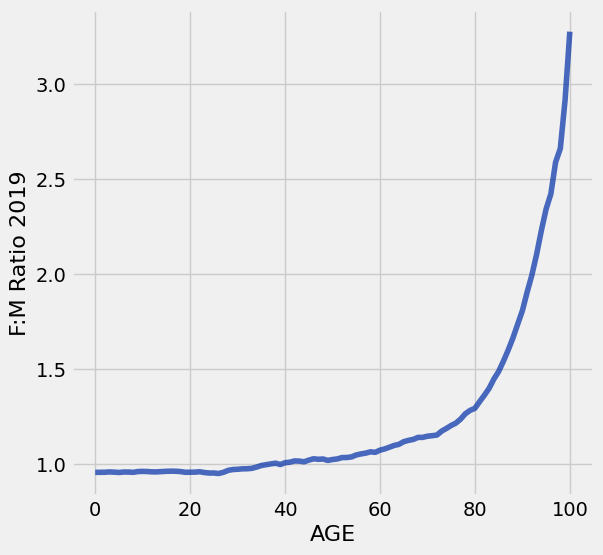

In [30]:
ratios.plot("AGE")